In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score
)

In [3]:
df = pd.read_csv("telecom_master.csv")

print(df.shape)
print(df["churn"].value_counts(normalize=True).round(3))
df.head()

(3000, 22)
churn
0    0.745
1    0.255
Name: proportion, dtype: float64


,customer_id,age,gender,region,plan_type,tenure_months,data_used_gb,call_minutes,calls_made,sms_count,...,network_issues,customer_service_calls,payment_delay,roaming_usage,international_calls,device_age_months,satisfaction_score,contract_type,auto_payment,churn
0,1001,56,Male,Kolkata,Prepaid,26,48.94,617,15,330,...,1,5,5,95,18,1,6,Two-Year,1,0
1,1002,69,Female,Chennai,Postpaid,59,55.45,302,45,10,...,2,6,5,57,14,48,1,Monthly,1,0
2,1003,46,Male,Delhi,Postpaid,33,49.69,155,118,291,...,4,9,1,2,44,16,4,Two-Year,0,0
3,1004,32,Male,Mumbai,Postpaid,41,56.98,413,96,147,...,4,9,1,29,6,43,6,Monthly,0,1
4,1005,60,Female,Mumbai,Postpaid,30,71.84,823,79,318,...,2,7,3,18,42,24,2,Two-Year,0,0


In [4]:
df["complaint_intensity"] = (
    df["complaints_6m"] /
    (df["tenure_months"] / 6).clip(lower=1)
)

df.head()

,customer_id,age,gender,region,plan_type,tenure_months,data_used_gb,call_minutes,calls_made,sms_count,...,customer_service_calls,payment_delay,roaming_usage,international_calls,device_age_months,satisfaction_score,contract_type,auto_payment,churn,complaint_intensity
0,1001,56,Male,Kolkata,Prepaid,26,48.94,617,15,330,...,5,5,95,18,1,6,Two-Year,1,0,0.692308
1,1002,69,Female,Chennai,Postpaid,59,55.45,302,45,10,...,6,5,57,14,48,1,Monthly,1,0,0.101695
2,1003,46,Male,Delhi,Postpaid,33,49.69,155,118,291,...,9,1,2,44,16,4,Two-Year,0,0,1.090909
3,1004,32,Male,Mumbai,Postpaid,41,56.98,413,96,147,...,9,1,29,6,43,6,Monthly,0,1,0.878049
4,1005,60,Female,Mumbai,Postpaid,30,71.84,823,79,318,...,7,3,18,42,24,2,Two-Year,0,0,1.200000


In [7]:
target = "churn"
leaky = ["retention_call_flag", "total_charges"]

def make_X(frame, drop):
    cols_to_drop = [target] + drop

    # customer_id sirf tab drop hoga jab column exist kare
    if "customer_id" in frame.columns:
        cols_to_drop.append("customer_id")

    X = frame.drop(columns=cols_to_drop, errors="ignore")
    return X

num_cols = make_X(df, leaky).select_dtypes(include=np.number).columns.tolist()
cat_cols = make_X(df, leaky).select_dtypes(exclude=np.number).columns.tolist()

print(len(num_cols), "numeric")
print(len(cat_cols), "categorical")
print("complaint_intensity" in num_cols)

17 numeric
4 categorical
True


In [8]:
X = make_X(df, leaky)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [9]:
pre = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]),
        num_cols
    ),
    (
        "cat",
        Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cat_cols
    )
])

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42
    )
}

results = []

for name, clf in models.items():

    pipe = Pipeline([
        ("pre", pre),
        ("clf", clf)
    ])

    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, proba),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "Accuracy": (pred == y_test).mean()
    })

comparison = pd.DataFrame(results).round(3)

print(comparison)

                 Model  ROC_AUC  Precision  Recall  Accuracy
0  Logistic Regression    0.451      0.000   0.000     0.745
1        Decision Tree    0.468      0.269   0.073     0.713
2        Random Forest    0.484      0.000   0.000     0.745


In [11]:
best = Pipeline([
    ("pre", pre),
    ("clf", models["Random Forest"])
])

best.fit(X_train, y_train)

proba = best.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(cm)

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

print("\nClassification Report")
print(classification_report(y_test, pred, digits=3))

Confusion Matrix
[[559   0]
 [191   0]]
TN = 559
FP = 0
FN = 191
TP = 0

Classification Report
              precision    recall  f1-score   support

           0      0.745     1.000     0.854       559
           1      0.000     0.000     0.000       191

    accuracy                          0.745       750
   macro avg      0.373     0.500     0.427       750
weighted avg      0.556     0.745     0.637       750



c:\Users\rohit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rohit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rohit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [12]:
baseline_accuracy = 1 - y_test.mean()

model_accuracy = (pred == y_test).mean()

print("Baseline Accuracy :", round(baseline_accuracy, 3))
print("Random Forest Accuracy :", round(model_accuracy, 3))

Baseline Accuracy : 0.745
Random Forest Accuracy : 0.745


In [13]:
rows = []

for t in np.arange(0.10, 0.65, 0.05):

    pred = (proba >= t).astype(int)

    rows.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "Flagged": int(pred.sum())
    })

sweep = pd.DataFrame(rows).round(3)

print(sweep)

    Threshold  Precision  Recall  Flagged
0        0.10      0.255   1.000      750
1        0.15      0.256   1.000      747
2        0.20      0.252   0.906      686
3        0.25      0.249   0.592      454
4        0.30      0.222   0.215      185
5        0.35      0.250   0.052       40
6        0.40      0.000   0.000        2
7        0.45      0.000   0.000        0
8        0.50      0.000   0.000        0
9        0.55      0.000   0.000        0
10       0.60      0.000   0.000        0


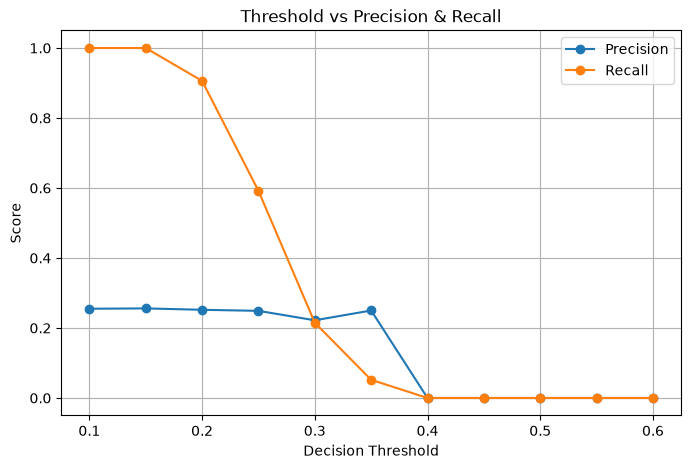

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    sweep["Threshold"],
    sweep["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    sweep["Threshold"],
    sweep["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision & Recall")

plt.grid(True)
plt.legend()

plt.show()

In [15]:
COST_FN = 5880
COST_FP = 300

sweep["Expected_Cost"] = 0

for i, t in enumerate(sweep["Threshold"]):

    pred = (proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    sweep.loc[i, "Expected_Cost"] = fn * COST_FN + fp * COST_FP

best_threshold = sweep.sort_values("Expected_Cost").head()

print(best_threshold)

   Threshold  Precision  Recall  Flagged  Expected_Cost
1       0.15      0.256   1.000      747         166800
0       0.10      0.255   1.000      750         167700
2       0.20      0.252   0.906      686         259740
3       0.25      0.249   0.592      454         560940
4       0.30      0.222   0.215      185         925200


In [16]:
# With leakage columns
X_leak = df.drop(columns=[target, "customer_id"])

num_leak = X_leak.select_dtypes(include=np.number).columns.tolist()
cat_leak = X_leak.select_dtypes(exclude=np.number).columns.tolist()

pre_leak = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]),
        num_leak
    ),
    (
        "cat",
        Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cat_leak
    )
])

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

rf_leak = Pipeline([
    ("pre", pre_leak),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42
    ))
])

rf_leak.fit(X_train_l, y_train_l)

auc_with_leak = roc_auc_score(
    y_test_l,
    rf_leak.predict_proba(X_test_l)[:,1]
)

# Without leakage columns
rf_clean = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42
    ))
])

rf_clean.fit(X_train, y_train)

auc_without_leak = roc_auc_score(
    y_test,
    rf_clean.predict_proba(X_test)[:,1]
)

print("ROC-AUC With Leakage :", round(auc_with_leak,3))
print("ROC-AUC Without Leakage :", round(auc_without_leak,3))

ROC-AUC With Leakage : 0.484
ROC-AUC Without Leakage : 0.484


In [17]:
comparison.to_csv("model_comparison.csv", index=False)
sweep.to_csv("threshold_sweep.csv", index=False)

print("✅ model_comparison.csv created")
print("✅ threshold_sweep.csv created")

✅ model_comparison.csv created
✅ threshold_sweep.csv created
